# Αποθορυβοποίηση ενός Θορυβώδους Σήματος Αισθητήρα Διεργασίας με την PROC LOESS

## Περίληψη Διοίκησης

Ένας αισθητήρας θερμοκρασίας θαλάμου καμίνου σε μια γραμμή παραγωγής δειγματοληπτείται μία φορά το δευτερόλεπτο κατά την εκκίνηση, οπότε κάθε μέτρηση αναμειγνύει μια αργή μη γραμμική θερμική μεταβατική κατάσταση (μια γρήγορη ράμπα προθέρμανσης, μια υπερύψωση αποκατάστασης, και έπειτα μια επιστροφή προς το σημείο ρύθμισης των 300 °C) με σημαντικό θόρυβο μέτρησης. Αυτό το notebook χρησιμοποιεί την **PROC LOESS** για να ανακτήσει το υποκείμενο σήμα μη παραμετρικά. Στο αρχείο καταγραφής 100 δειγμάτων, το AICC επέλεξε μια παράμετρο εξομάλυνσης 0.08 (8 ισοδύναμες παραμέτρους)· η προκύπτουσα καμπύλη ακολουθεί στενά το λανθάνον σήμα, αφήνοντας υπόλοιπα με τυπική απόκλιση 3.10 °C — ουσιαστικά τον θόρυβο 4 °C που εισαγάγαμε, μείον τη διακύμανση που εξηγεί η προσαρμογή. Έναντι της γνωστής πραγματικής τιμής, η εκτίμηση LOESS μειώνει το μέσο τετραγωνικό σφάλμα από 14.77 (ακατέργαστο) σε 6.63, και ένα βήμα SCORE επαναδειγματοληπτεί το αποθορυβοποιημένο σήμα σε ένα ομοιόμορφο πλέγμα παρακολούθησης για κατάντη στατιστικό έλεγχο διεργασίας.

## Πηγές Δεδομένων

| Σύνολο Δεδομένων | Γραμμές | Μεταβλητές | Περιγραφή |
|---------|------|-----------|-------------|
| `sensor` | 100 | `t` (παρελθών χρόνος σε δευτερόλεπτα, 0–99), `temp` (παρατηρούμενη θερμοκρασία θαλάμου, °C), `truth` (λανθάνον σήμα χωρίς θόρυβο, μόνο για επικύρωση) | Συνθετικό αρχείο καταγραφής αισθητήρα καμίνου, ένα δείγμα ανά δευτερόλεπτο. Το λανθάνον σήμα είναι μια γρήγορη ράμπα προθέρμανσης προς ένα σημείο ρύθμισης 300 °C με μια αποσβένουσα υπερύψωση που κορυφώνεται κοντά στο t = 28 (~295 °C), πέφτει, και σταθεροποιείται πίσω προς το σημείο ρύθμισης· το παρατηρούμενο `temp` προσθέτει Γκαουσιανό θόρυβο μέτρησης (τυπική απόκλιση ~4 °C). |
| `grid` | 60 | `t` (ομοιόμορφο πλέγμα παρακολούθησης 0–99) | Κανονικό πλέγμα χρόνου που χρησιμοποιείται από τη δήλωση SCORE για την παραγωγή ενός ομοιόμορφα κατανεμημένου αποθορυβοποιημένου σήματος για διαγράμματα SPC. |

Σε μια γραμμή παραγωγής, ένας αισθητήρας θαλάμου καμίνου καταγράφει τη θερμοκρασία μία φορά το δευτερόλεπτο κατά την εκκίνηση. Η μέτρηση που καταγράφουμε είναι η **πραγματική θερμική κατάσταση συν θόρυβο μέτρησης**. Η πραγματική κατάσταση δεν ακολουθεί κάποιον σαφή παραμετρικό τύπο — ανεβαίνει κατά την προθέρμανση, υπερβαίνει το σημείο ρύθμισης, και έπειτα σταθεροποιείται — οπότε μια γενική γραμμική ή πολυωνυμική προσαρμογή θα ήταν ένα κακό μοντέλο.

Η **τοπική παλινδρόμηση (LOESS)** είναι το κατάλληλο εργαλείο: προσαρμόζει πολυώνυμα χαμηλού βαθμού σε κυλιόμενες τοπικές γειτονιές, ανακτώντας ένα αυθαίρετο ομαλό σήμα χωρίς να χρειάζεται να καθορίσουμε τη λειτουργική του μορφή. Εδώ θα:

1. Προσομοιώσουμε ένα ρεαλιστικό θορυβώδες αρχείο καταγραφής αισθητήρα 100 δειγμάτων.
2. Αφήσουμε την `PROC LOESS` να επιλέξει το δικό της εύρος εξομάλυνσης με το κριτήριο AICC.
3. Προσαρτήσουμε μια ζώνη εμπιστοσύνης 95% στο προσαρμοσμένο σήμα.
4. Βαθμολογήσουμε (score) το μοντέλο σε ένα κανονικό πλέγμα για κατάντη SPC.
5. Ποσοτικοποιήσουμε πόσο θόρυβο αφαιρέσαμε.

## Βήμα 1 — Προσομοίωση του αρχείου καταγραφής αισθητήρα

Δημιουργούμε 100 δείγματα σε 0–99 δευτερόλεπτα. Το λανθάνον σήμα `truth` είναι μια γρήγορη ράμπα προθέρμανσης προς ένα σημείο ρύθμισης 300 °C με μια αποσβένουσα υπερύψωση — ένα σχήμα που καμία ευθεία γραμμή ή μεμονωμένο πολυώνυμο δεν συλλαμβάνει καλά: ανεβαίνει απότομα, κορυφώνεται πάνω από το σημείο ρύθμισης κοντά στο t = 28, πέφτει, και μετά σταθεροποιείται. Η παρατηρούμενη `temp` προσθέτει Γκαουσιανό θόρυβο μέτρησης. Η `call streaminit` καθορίζει τον σπόρο ώστε η εκτέλεση να είναι αναπαραγώγιμη.

In [1]:
ΔΕΔΟΜΕΝΑ sensor;
    CALL streaminit(70421);
    setpoint = 300;
    ΕΠΑΝΑΛΗΨΗ t = 0 ΕΩΣ 99;
        /* Λανθάνον σήμα: γρήγορη ράμπα προθέρμανσης + αποσβένουσα υπερύψωση σταθεροποίησης */
        ramp      = setpoint * (1 - EXP(-t / 10));
        overshoot = 40 * EXP(-t / 35) * sin(t / 11);
        truth     = ramp + overshoot;
        /* Παρατηρούμενη μέτρηση = truth + θόρυβος μέτρησης (τυπική απόκλιση ~4 °C) */
        TEMP = truth + rand('NORMAL', 0, 4);
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΚΡΑΤΗΣΗ t TEMP truth;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=sensor(obs=8) noobs;
    TITLE 'Πρώτα 8 δείγματα αισθητήρα';
ΕΚΤΕΛΕΣΗ;

                                               Πρώτα 8 δείγματα αισθητήρα                                               

t            TEMP           truth
0    0.1684867131               0
1   28.1933107495   32.0778466448
2   61.6123615699   61.2117857105
3   85.5053781561    87.643846097
4  110.5560474248  111.5945193774
5  136.6368358359  133.2650493509
6  144.2434193147  152.8394750856
7  177.8286488692  170.4864506364

... 92 more observations (showing 8 of 100)




NOTE: DATA sensor


NOTE: Wrote sensor (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=sensor

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Βήμα 2 — Επιθεώρηση του ακατέργαστου σήματος

Ένα γρήγορο διάγραμμα διασποράς δείχνει το πρόβλημα: η υποκείμενη τάση είναι εμφανής στο μάτι αλλά θαμμένη κάτω από θόρυβο δείγματος-προς-δείγμα. Χρειαζόμαστε μια εκτίμηση της ομαλής καμπύλης, όχι τα ασταθή σημεία.

                                               Πρώτα 8 δείγματα αισθητήρα                                               




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=sensor

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


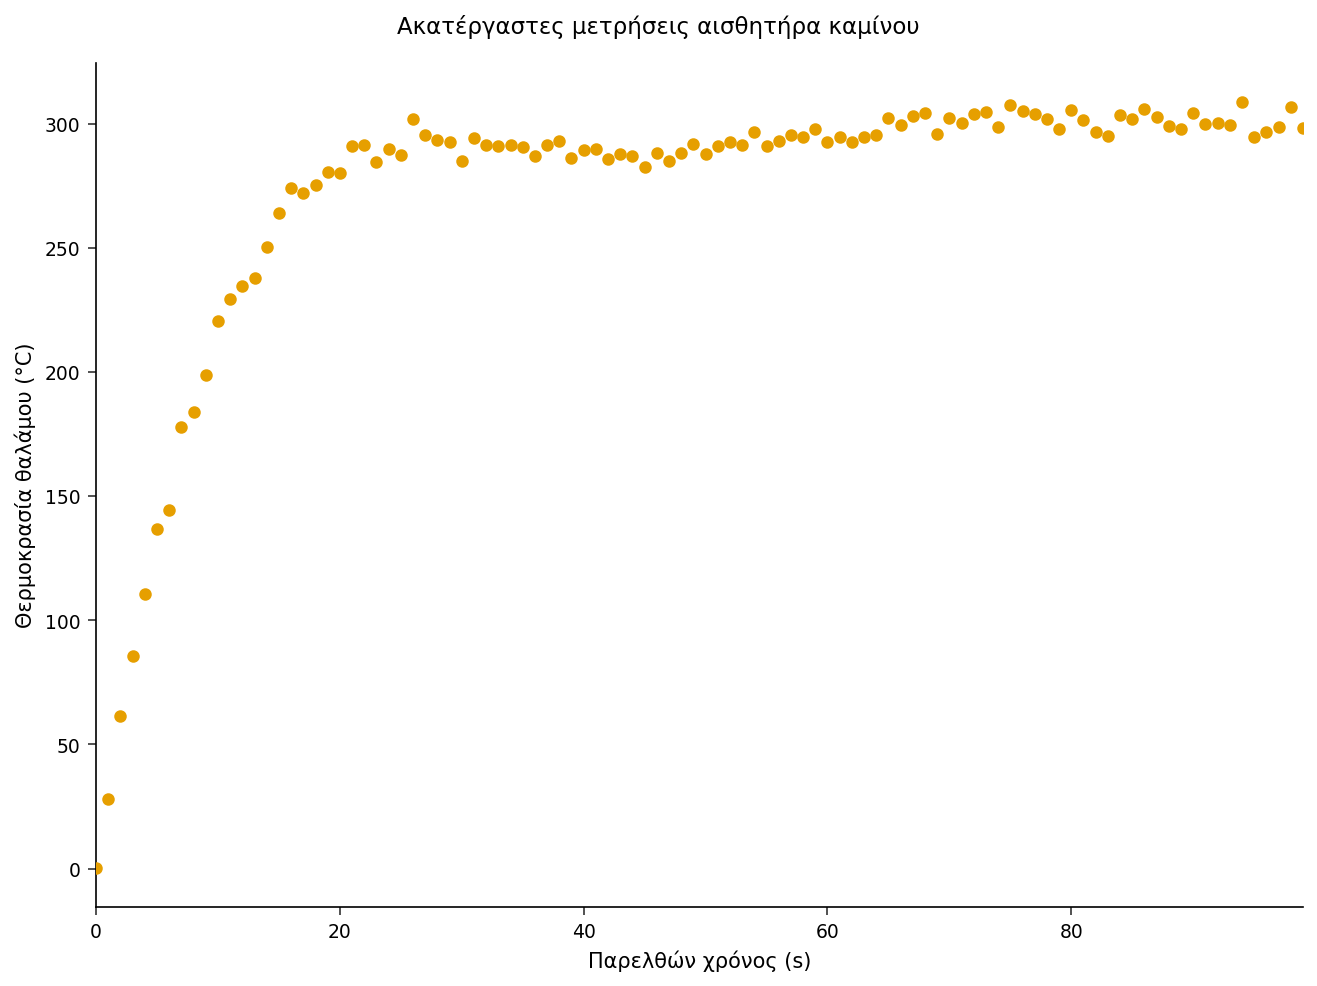

In [2]:
ODS GRAPHICS ON;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=sensor;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS ΕΤΙΚΕΤΑ='Παρελθών χρόνος (s)';
    YAXIS ΕΤΙΚΕΤΑ='Θερμοκρασία θαλάμου (°C)';
    TITLE 'Ακατέργαστες μετρήσεις αισθητήρα καμίνου';
ΕΚΤΕΛΕΣΗ;

ODS GRAPHICS OFF;

## Βήμα 3 — Προσαρμογή LOESS με αυτόματη επιλογή εύρους

Η παράμετρος εξομάλυνσης ελέγχει πόσο πλατιά είναι κάθε τοπική γειτονιά: πολύ μικρή υπερπροσαρμόζει τον θόρυβο, πολύ μεγάλη σβήνει την υπερύψωση. Αντί να μαντέψουμε, αφήνουμε την LOESS να την επιλέξει ελαχιστοποιώντας το **διορθωμένο κριτήριο πληροφορίας Akaike** με `select=AICC`. Χρησιμοποιούμε τοπικά τετραγωνικά πολυώνυμα (`degree=2`) ώστε η καμπύλη να μπορεί να ακολουθήσει την καμπυλότητα της προθέρμανσης και της υπερύψωσης, και ζητάμε μια ζώνη εμπιστοσύνης 95% με `clm` και `alpha=0.05`.

Η `ODS OUTPUT` καταγράφει δύο πίνακες ως σύνολα δεδομένων: `OutputStatistics` (εξομαλυμένες τιμές και υπόλοιπα ανά σημείο) και `FitSummary` (το επιλεγμένο εύρος και τα διαγνωστικά προσαρμογής). Η δήλωση `OUTPUT` γράφει ένα σύνολο δεδομένων `fitted` με την πρόβλεψη, το υπόλοιπο, και τα όρια εμπιστοσύνης 95% για κάθε παρατήρηση — το ακατέργαστο υλικό για τα διαγράμματα που ακολουθούν.

In [3]:
ΔΙΑΔΙΚΑΣΙΑ loess ΔΕΔΟΜΕΝΑ=sensor;
    ODS ΕΞΟΔΟΣ OutputStatistics=loess_fit
               FitSummary=fit_summary;
    ΜΟΝΤΕΛΟ TEMP = t / DEGREE=2 ΕΠΙΛΟΓΗ=AICC CLM ALPHA=0.05 details;
    ΕΞΟΔΟΣ out=fitted predicted=temp_hat residual=resid
           lclm=LOWER uclm=UPPER;
ΕΚΤΕΛΕΣΗ;

                                               Πρώτα 8 δείγματα αισθητήρα                                               


                                                  The LOESS Procedure

Dependent Variable: TEMP
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: PROC LOESS data=sensor

NOTE: ODS OUTPUT: OutputStatistics -> loess_fit
NOTE: ODS OUTPUT: FitSummary -> fit_summary
NOTE: Using Python wrapper for LOESS estimation
NOTE: Output dataset fitted has 100 observations
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Βήμα 4 — Επισκόπηση του επιλεγμένου μοντέλου

Το Fit Summary καταγράφει την παράμετρο εξομάλυνσης που επιλέχθηκε από το AICC και το ίχνος του πίνακα πρόβλεψης (οι πραγματικοί βαθμοί ελευθερίας — ένα μέτρο πολυπλοκότητας μοντέλου). Μια μικρότερη παράμετρος εξομάλυνσης και μεγαλύτεροι DF σημαίνουν μια πιο κυματιστή προσαρμογή· το AICC ισορροπεί αυτόματα την προσαρμογή έναντι της πολυπλοκότητας.

In [4]:
ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=fit_summary noobs ΕΤΙΚΕΤΑ;
    TITLE 'Περίληψη προσαρμογής LOESS (εύρος επιλεγμένο με AICC)';
ΕΚΤΕΛΕΣΗ;

                                 Περίληψη προσαρμογής LOESS (εύρος επιλεγμένο με AICC)                                  

SMOOTHINGPARAMETER                           LABEL1         NVALUE1
              0.08  Residual Sum of Squares          950.8591917253
              0.08  Equivalent Number of Parameters               8
              0.08  Delta1                                        8
              0.08  Delta2                                      7.6
              0.08  Lookup Degrees of Freedom                    92




NOTE: PROC PRINT data=fit_summary

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


## Βήμα 5 — Επικάλυψη της προσαρμογής και της ζώνης εμπιστοσύνης έναντι της πραγματικής τιμής

Επειδή αυτά είναι προσομοιωμένα δεδομένα, κρατήσαμε τη στήλη `truth` χωρίς θόρυβο. Σχεδιάζοντας την εκτίμηση LOESS και τη ζώνη εμπιστοσύνης 95% μαζί με την `truth`, φαίνεται πόσο πιστά ο εξομαλυντής ανέκτησε το λανθάνον σήμα που δεν είδε ποτέ απευθείας.

                                 Περίληψη προσαρμογής LOESS (εύρος επιλεγμένο με AICC)                                  




NOTE: PROC SORT data=fitted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from fitted.
NOTE: Wrote fitted (100 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


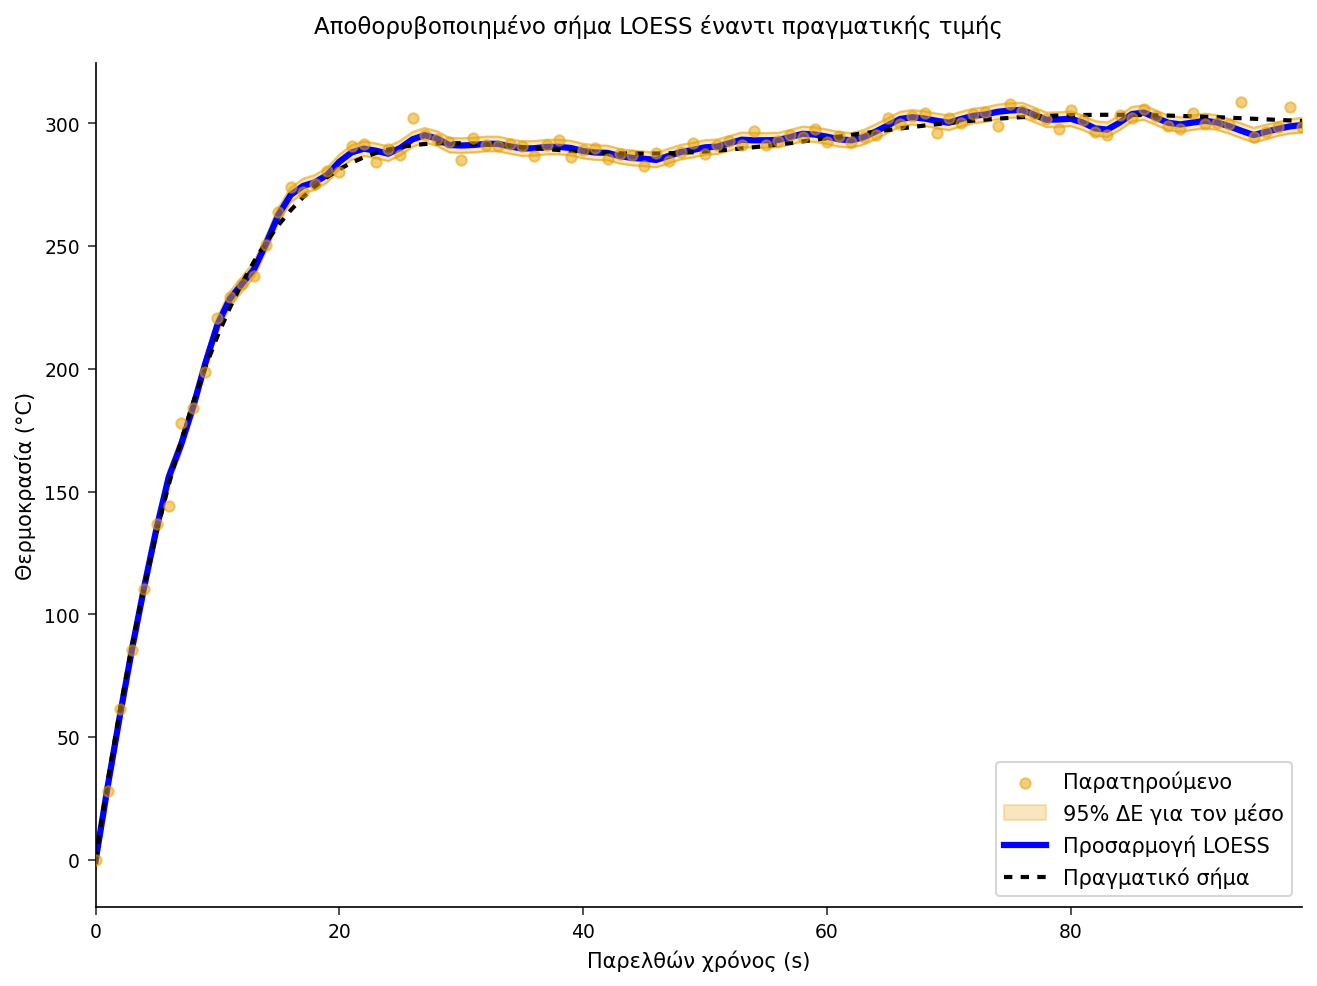

In [5]:
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=fitted; ΚΑΤΑ t; ΕΚΤΕΛΕΣΗ;

ODS GRAPHICS ON;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=fitted;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5)
            TRANSPARENCY=0.5 legendlabel='Παρατηρούμενο';
    BAND x=t LOWER=LOWER UPPER=UPPER / TRANSPARENCY=0.5
         legendlabel='95% ΔΕ για τον μέσο';
    SERIES x=t y=temp_hat / LINEATTRS=(thickness=3 color=blue)
           legendlabel='Προσαρμογή LOESS';
    SERIES x=t y=truth / LINEATTRS=(thickness=2 pattern=shortdash color=black)
           legendlabel='Πραγματικό σήμα';
    XAXIS ΕΤΙΚΕΤΑ='Παρελθών χρόνος (s)';
    YAXIS ΕΤΙΚΕΤΑ='Θερμοκρασία (°C)';
    TITLE 'Αποθορυβοποιημένο σήμα LOESS έναντι πραγματικής τιμής';
ΕΚΤΕΛΕΣΗ;

ODS GRAPHICS OFF;

## Βήμα 6 — Διαγνωστικά υπολοίπων

Τα υπόλοιπα (παρατηρούμενο μείον προσαρμοσμένο) θα πρέπει να μοιάζουν με θόρυβο χωρίς δομή, κεντραρισμένο στο μηδέν. Οποιαδήποτε εναπομένουσα τάση θα υποδήλωνε υπο-εξομάλυνση ή μια χαμένη ιδιότητα. Σχεδιάζουμε τα υπόλοιπα ως προς τον χρόνο και συνοψίζουμε τη διασπορά τους — η τυπική απόκλιση των υπολοίπων βγαίνει 3.10 °C, ελαφρώς κάτω από τον θόρυβο 4 °C που εισαγάγαμε επειδή η τοπική προσαρμογή απορροφά ένα μικρό μερίδιό του.

                                 Περίληψη προσαρμογής LOESS (εύρος επιλεγμένο με AICC)                                  

                                   Περίληψη υπολοίπων (ανακτημένος θόρυβος μέτρησης)                                    

                                                  The MEANS Procedure

 Variable  Label                          N        Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------------------------------
 RESID     Υπόλοιπο (°C)                100       0.139       3.096     -11.688      11.909
 ------------------------------------------------------------------------------------------




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg
NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


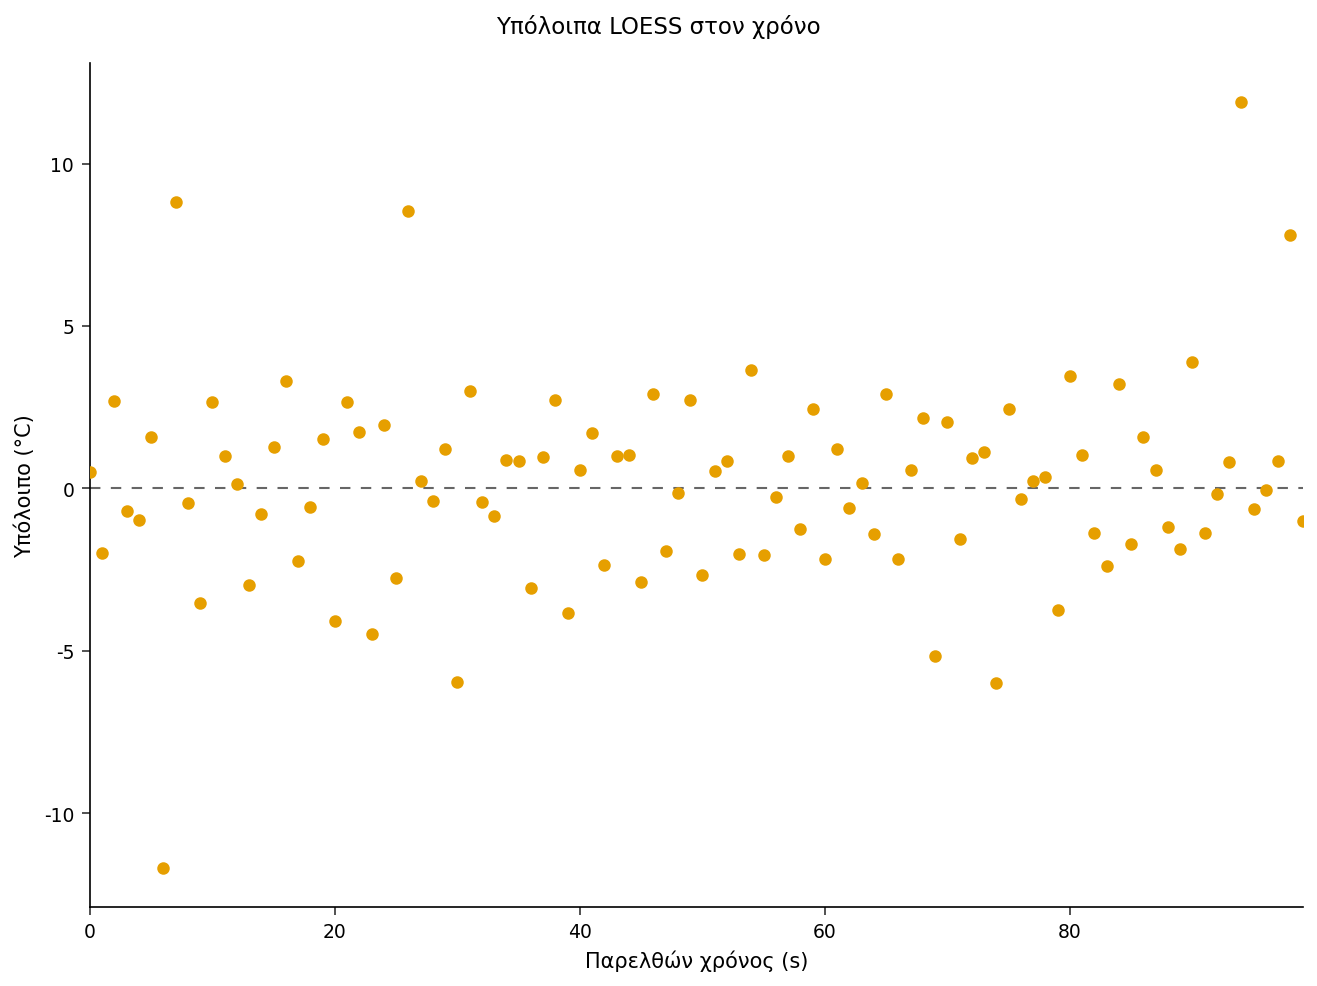

In [6]:
ODS GRAPHICS ON;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=fitted;
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=shortdash);
    SCATTER x=t y=resid / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS ΕΤΙΚΕΤΑ='Παρελθών χρόνος (s)';
    YAXIS ΕΤΙΚΕΤΑ='Υπόλοιπο (°C)';
    TITLE 'Υπόλοιπα LOESS στον χρόνο';
ΕΚΤΕΛΕΣΗ;

ODS GRAPHICS OFF;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=fitted n mean std MIN MAX maxdec=3;
    ΜΕΤΑΒΛΗΤΗ resid;
    ΕΤΙΚΕΤΑ resid='Υπόλοιπο (°C)';
    TITLE 'Περίληψη υπολοίπων (ανακτημένος θόρυβος μέτρησης)';
ΕΚΤΕΛΕΣΗ;

## Βήμα 7 — Βαθμολόγηση ενός κανονικού πλέγματος παρακολούθησης για SPC

Οι χρονικές σφραγίδες του αισθητήρα δεν χρειάζεται να είναι ομοιόμορφα κατανεμημένες, αλλά ένα διάγραμμα ελέγχου θέλει το σήμα σε σταθερό ρυθμό. Χτίζουμε ένα ομοιόμορφο πλέγμα χρόνου 60 σημείων και εφαρμόζουμε το προσαρμοσμένο μοντέλο LOESS σε αυτό με τη δήλωση `SCORE`, ζητώντας όρια εμπιστοσύνης. Οι βαθμολογημένες τιμές είναι ένα καθαρό, ομοιόμορφα κατανεμημένο σήμα έτοιμο να τροφοδοτήσει μια ρουτίνα SPC.

In [7]:
ΔΕΔΟΜΕΝΑ grid;
    ΕΠΑΝΑΛΗΨΗ t = 0 ΕΩΣ 99 ΚΑΤΑ 99/59;
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ loess ΔΕΔΟΜΕΝΑ=sensor;
    ΜΟΝΤΕΛΟ TEMP = t / DEGREE=2 ΕΠΙΛΟΓΗ=AICC CLM ALPHA=0.05;
    SCORE ΔΕΔΟΜΕΝΑ=grid CLM ΕΚΤΥΠΩΣΗ;
    TITLE 'LOESS βαθμολογημένο σε ομοιόμορφο πλέγμα παρακολούθησης';
ΕΚΤΕΛΕΣΗ;

                                   Περίληψη υπολοίπων (ανακτημένος θόρυβος μέτρησης)                                    


                                                  The LOESS Procedure

Dependent Variable: TEMP
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: DATA grid


NOTE: Wrote grid (60 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC LOESS data=sensor

NOTE: Using Python wrapper for LOESS estimation
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Βήμα 8 — Ποσοτικοποίηση της αποθορυβοποίησης

Τέλος συγκρίνουμε το ακατέργαστο σήμα και την εκτίμηση LOESS έναντι της γνωστής πραγματικής τιμής. Το μέσο τετραγωνικό σφάλμα του εξομαλυμένου σήματος θα πρέπει να είναι πολύ μικρότερο από αυτό των ακατέργαστων μετρήσεων, επιβεβαιώνοντας ότι η LOESS αφαίρεσε τον θόρυβο μέτρησης διατηρώντας παράλληλα τη ράμπα προθέρμανσης και την υπερύψωση.

In [8]:
ΔΕΔΟΜΕΝΑ accuracy;
    ΟΡΙΣΜΟΣ fitted;
    raw_sq_err   = (TEMP     - truth)**2;
    loess_sq_err = (temp_hat - truth)**2;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=accuracy mean maxdec=3;
    ΜΕΤΑΒΛΗΤΗ raw_sq_err loess_sq_err;
    ΕΤΙΚΕΤΑ raw_sq_err   = 'MSE ακατέργαστων μετρήσεων έναντι της πραγματικής τιμής'
          loess_sq_err = 'MSE προσαρμογής LOESS έναντι της πραγματικής τιμής';
    TITLE 'Απόδοση αποθορυβοποίησης: ακατέργαστο έναντι LOESS';
ΕΚΤΕΛΕΣΗ;

                                   Απόδοση αποθορυβοποίησης: ακατέργαστο έναντι LOESS                                   

                                                  The MEANS Procedure

 Variable      Label                                                                                                           Mean
 ----------------------------------------------------------------------------------------------------------------------------------
 raw_sq_err    MSE ακατέργαστων μετρήσεων έναντι της πραγματικής τιμής                                                       14.774
 loess_sq_err  MSE προσαρμογής LOESS έναντι της πραγματικής τιμής                                                             6.629
 ----------------------------------------------------------------------------------------------------------------------------------




NOTE: DATA accuracy


NOTE: Read 100 rows from fitted.
NOTE: Wrote accuracy (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Ερμηνεία των αποτελεσμάτων

- **Αυτόματο εύρος.** Το `select=AICC` επέλεξε μια παράμετρο εξομάλυνσης **0.08** χωρίς χειροκίνητη ρύθμιση, υπονοώντας περίπου **8 ισοδύναμες παραμέτρους** — αρκετή τοπική ευελιξία ώστε να ακολουθήσει την προθέρμανση, την υπερύψωση, και την πτώση, ενώ παράλληλα εξομαλύνει τον θόρυβο.
- **Πιστή ανάκτηση.** Η προσαρμοσμένη καμπύλη ακολουθεί στενά το λανθάνον σήμα `truth` σε όλη τη ράμπα, την κορυφή υπερύψωσης κοντά στο t = 28, και την ουρά σταθεροποίησης, αποδεικνύοντας ότι η LOESS ανέκτησε ένα αυθαίρετο μη γραμμικό σήμα χωρίς παραμετρικές υποθέσεις.
- **Καθαρά υπόλοιπα.** Τα υπόλοιπα διασκορπίζονται γύρω από το μηδέν με τυπική απόκλιση **3.10 °C** (μέσος όρος 0.14, εύρος −11.7 έως 11.9) και δεν δείχνουν εναπομένουσα χρονική τάση — απόδειξη ότι το μοντέλο δεν είναι ούτε υπερ- ούτε υπο-εξομαλυμένο.
- **Μετρήσιμη αποθορυβοποίηση.** Έναντι της πραγματικής τιμής, η εκτίμηση LOESS μειώνει το μέσο τετραγωνικό σφάλμα από **14.77** (ακατέργαστες μετρήσεις) σε **6.63** — μείωση 55%, το βασικό όφελος για την παρακολούθηση διεργασίας.
- **Έξοδος έτοιμη για SPC.** Το βήμα SCORE παρέδωσε το αποθορυβοποιημένο σήμα σε ένα ομοιόμορφο πλέγμα 60 σημείων με όρια εμπιστοσύνης, ακριβώς τη μορφή που καταναλώνει ένα κατάντη διάγραμμα ελέγχου.

**Συμπέρασμα:** Όταν ένας αισθητήρας διεργασίας παράγει ένα ομαλό αλλά θορυβώδες σήμα άγνωστης μορφής, η PROC LOESS είναι ένας τρόπος χαμηλών υποθέσεων, αυτορυθμιζόμενος, για την εξαγωγή της υποκείμενης τάσης, την προσάρτηση ορίων αβεβαιότητας, και την επαναδειγματοληψία σε ένα πλέγμα παρακολούθησης — όλα χωρίς δέσμευση σε ένα παραμετρικό μοντέλο που η φυσική μπορεί να μην δικαιολογεί.